# 使い方： `py4project`

In [1]:
import pandas as pd
import py4project as pyp

## データ

データ：経済センサス

- `w2016`：2016年従業者数
- `w2021`：2021年従業者数
- `e2016`：2016年事業所数
- `e2021`：2021年事業所数

In [2]:
df = pd.read_csv('data_project.csv')
df

,地域コード,地域,産業コード,産業,w2016,w2021,e2016,e2021
0,0,全国,AB,農林漁業,363024,453703,32676,42458
1,0,全国,C,鉱業，採石業，砂利採取業,19467,19697,1851,1865
2,0,全国,D,建設業,3690740,3737415,492734,485135
3,0,全国,E,製造業,8864253,8803643,454800,412617
4,0,全国,F,電気・ガス・熱供給・水道業,187818,202149,4654,9139
5,0,全国,G,情報通信業,1642042,1986839,63574,76559
6,0,全国,H,運輸業，郵便業,3197231,3264734,130459,128224
7,0,全国,I,卸売業，小売業,11843869,11611924,1355060,1228920
8,0,全国,J,金融業，保険業,1530002,1494436,84041,83852
9,0,全国,K,不動産業，物品賃貸業,1462395,1618138,353155,374456


## ボックスプロット

In [3]:
help(pyp.box_plot)

Help on function box_plot in module py4project.core:

box_plot(x, data, title=None, text_col=None, xlabel=None, xlog=False)
    箱ひげ図を表示する。

    データの散らばり方（中央値・四分位数・外れ値）を確認するための図です。
    箱の中の線が中央値、三角の印が平均値を表します。
    text_col を指定すると、外れ値の横に名前が表示されるので、
    どの産業や都道府県が極端な値をとっているかが分かります。

    引数
    ----
    x : 文字列 または 文字列のリスト
        箱ひげ図にする変数の列名。
        リストで複数渡すと、横に並べて比較できます。
        例： x='地域固有効果'
        例： x=['全国成長効果', '産業構成効果', '地域固有効果']
    data : DataFrame
        xの列を含むデータフレーム。
    title : 文字列
        グラフの上に表示するタイトル。省略するとタイトルなしになります。
    text_col : 文字列
        外れ値の横に表示する名前が入っている列名。
        省略すると名前は表示されず、外れ値は点だけで表示されます。
        例： text_col='産業'、text_col='都道府県'
        名前は先頭6文字までが表示されます。
    xlabel : 文字列のリスト
        横軸に表示するラベルのリスト。
        省略するとxの列名がそのまま使われます。
    xlog : True または False
        Trueでデータを常用対数（log10）に変換してから箱ひげ図を描きます。

    使用例
    ------
    >>> box_plot('地域固有効果', df)
    >>> box_plot(['全国成長効果', '産業構成効果', '地域固有効果'], df)
    >>> box_plot('地域固有効果', df, text_col='産業')
    >>> 

2016年の従業者数のボックスプロットを表示する。

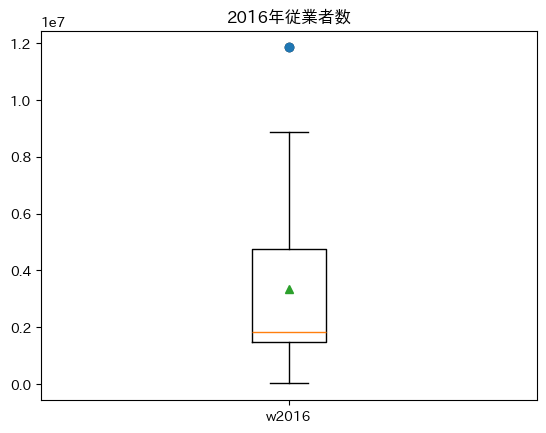

In [4]:
pyp.box_plot(x='w2016', data=df, title='2016年従業者数')

外れ値に産業名を表示したい場合は `text_col` を指定する。

指定しない場合、外れ値は点だけで表示される。

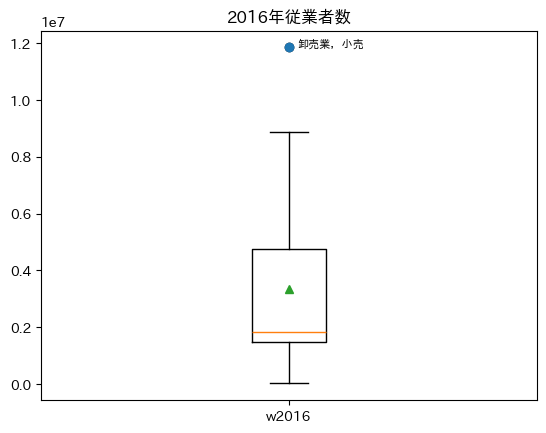

In [5]:
pyp.box_plot(x='w2016', data=df, title='2016年従業者数',
             text_col='産業'   # 外れ値の横に表示する名前が入っている列
)

2016年と2021年の従業者数および事業所数のボックスプロットを表示する。

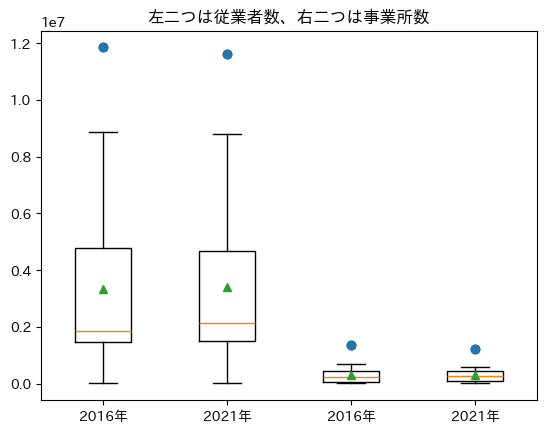

In [6]:
cols = ['w2016', 'w2021', 'e2016', 'e2021']
labels = ['2016年', '2021年', '2016年', '2021年']
pyp.box_plot(x=cols, data=df, xlabel=labels,
             title='左二つは従業者数、右二つは事業所数')

## 横バープロット

In [7]:
help(pyp.bar_plot)

Help on function bar_plot in module py4project.core:

bar_plot(x, data, title=None, xlabel=None, unit=1000, sort_by='産業コード', tick_label='産業', ascending=None)
    横向きの棒グラフを表示する。

    産業ごとの値を横に並べた棒グラフを描きます。
    複数の列をリストで渡すと、それぞれを並べて比較できます。
    シフトシェア分析の3つの効果（全国成長効果・産業構成効果・地域固有効果）は
    授業資料と同じ色で自動的に塗り分けられます。

    引数
    ----
    x : 文字列 または 文字列のリスト
        棒の長さにする変数の列名。
        リストで複数渡すと、産業ごとに並べて表示されます。
        例： x='地域固有効果'
        例： x=['全国成長効果', '産業構成効果', '地域固有効果']
    data : DataFrame
        xの列を含むデータフレーム。
    title : 文字列
        グラフの上に表示するタイトル。省略するとタイトルなしになります。
    xlabel : 文字列
        横軸のラベル。省略すると列名と単位から自動でつくられます。
    unit : 数値 または 辞書
        値を割る数。表示の桁を調整するために使います。
        1000 なら千単位、0.01 なら百分率（％）の表示になります。
        列ごとに変えたい場合は辞書で渡します。
        例： unit={'地域固有効果': 1000, '特化係数': 1}
    sort_by : 文字列 または None
        棒を並べる順番を決める列名。初期値は '産業コード' です。
        Noneを渡すと、xの最初の列の値で並べ替えます。
    tick_label : 文字列
        縦軸に表示する名前が入っている列名。初期値は '産業' です。
        都道府県ごとのグラフを描く場合は tick_label='都道府県' と指定

2016年従業者数の産業別バープロットを表示する。

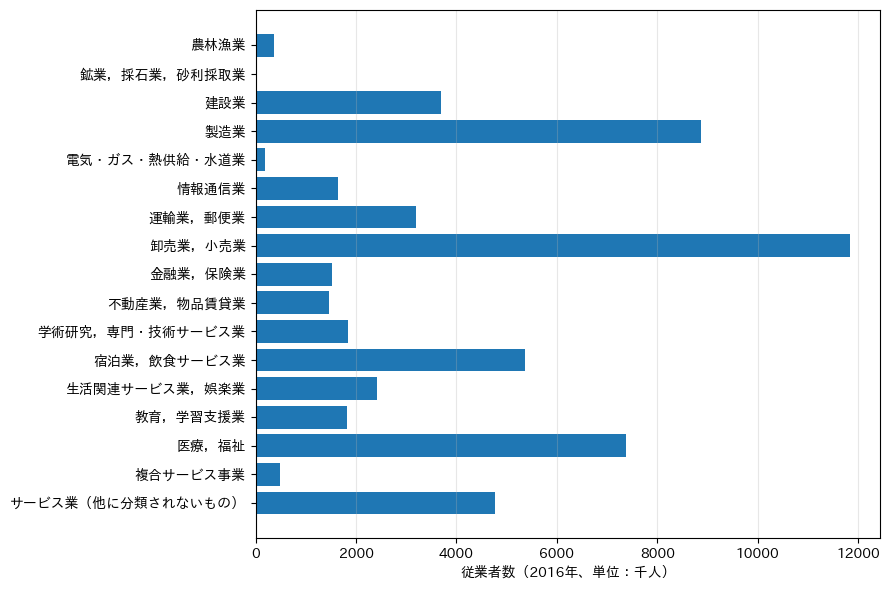

In [8]:
pyp.bar_plot('w2016', data=df, xlabel='従業者数（2016年、単位：千人）')

2016年と2021年の従業者数の産業別バープロットを表示する。

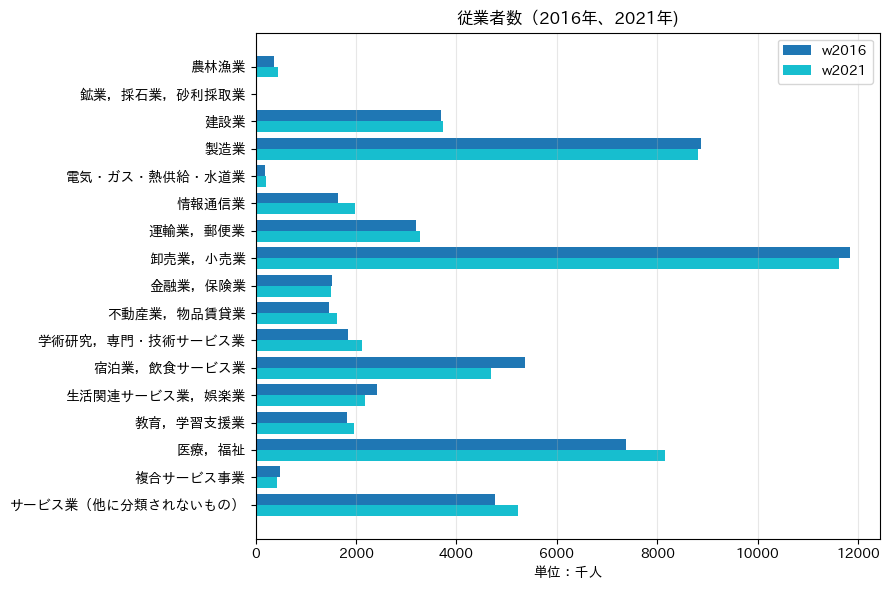

In [9]:
pyp.bar_plot(['w2016','w2021'], data=df, title='従業者数（2016年、2021年)', xlabel='単位：千人')

従業者数・事業所数の2016年から2021年にかけて変化率（パーセント表示）をバープロットとして表示する。

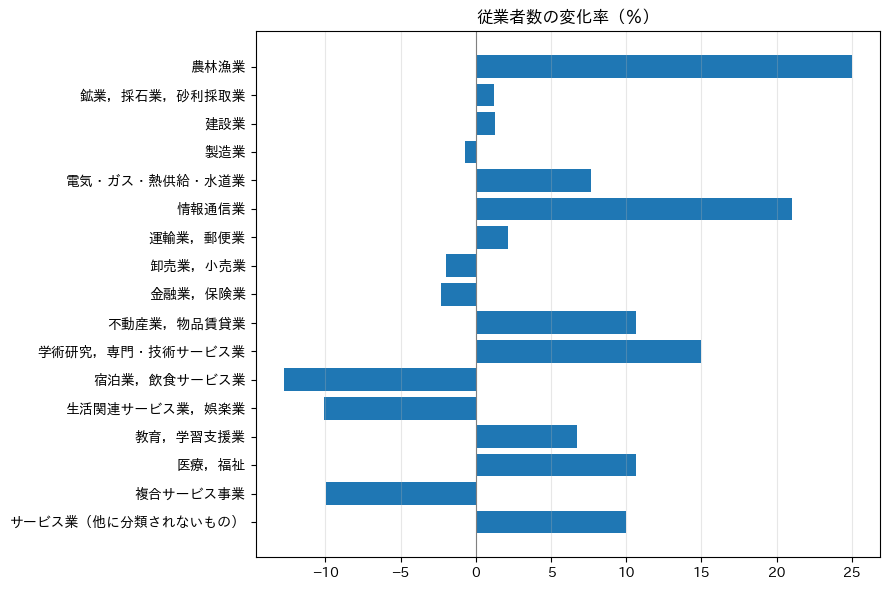

In [10]:
df['w変化率'] = df['w2021'] / df['w2016'] - 1
pyp.bar_plot('w変化率', data=df, title='従業者数の変化率（％）', xlabel='', unit=0.01)

## 散布図

In [11]:
help(pyp.scatter_plot)

Help on function scatter_plot in module py4project.core:

scatter_plot(x, y, data, title=None, xlabel=None, ylabel=None, line=True, text_col=None, xlog=False, ylog=False, xylog=False)
    散布図にトレンド線を重ねて表示する。

    regression_plotとよく似ていますが、こちらは推定式を表示せず、
    データの傾向を目で確かめることを目的としています。
    値の大きさが極端に違う変数を扱うときは、対数化のオプションが使えます。

    引数
    ----
    x : 文字列
        横軸にする変数の列名。
    y : 文字列
        縦軸にする変数の列名。
    data : DataFrame
        xとyの列を含むデータフレーム。
        xまたはyが欠けている行は、作図と計算から自動的に除かれます。
    title : 文字列
        グラフの上に表示するタイトル。省略するとタイトルなしになります。
    xlabel : 文字列
        横軸のラベル。省略するとxの列名がそのまま使われます。
    ylabel : 文字列
        縦軸のラベル。省略するとyの列名がそのまま使われます。
    line : True または False
        Trueでトレンド線（当てはめた直線）を引きます。
    text_col : 文字列
        各点の横に表示する名前が入っている列名。
        省略すると名前は表示されません。
        例： text_col='産業'、text_col='都道府県'
        名前は先頭6文字までが表示されます。
    xlog : True または False
        Trueで横軸の変数を常用対数（log10）に変換します。
    ylog : True または False
        Trueで縦軸の変数を常用対数（log10）に変換します。
    xylog : True または

2016年事業所数と従業者数の散布図を表示する。

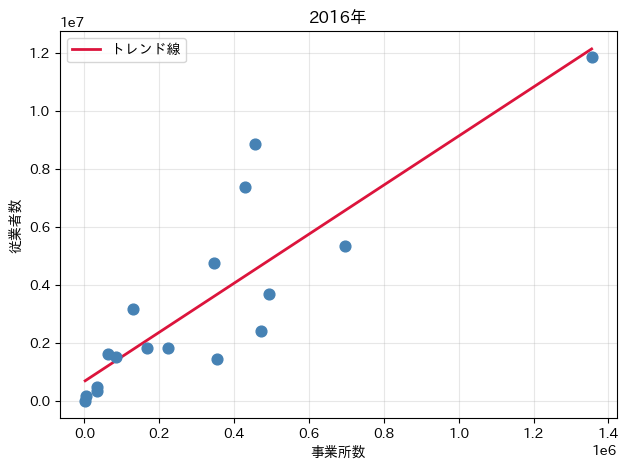

In [12]:
pyp.scatter_plot(x='e2016', y='w2016', data=df,
                 title='2016年', xlabel='事業所数', ylabel='従業者数'
)

常用対数に変換して2016年事業所数と従業者数の散布図を表示する。ただし、マーカーに産業名を追加しなさい。

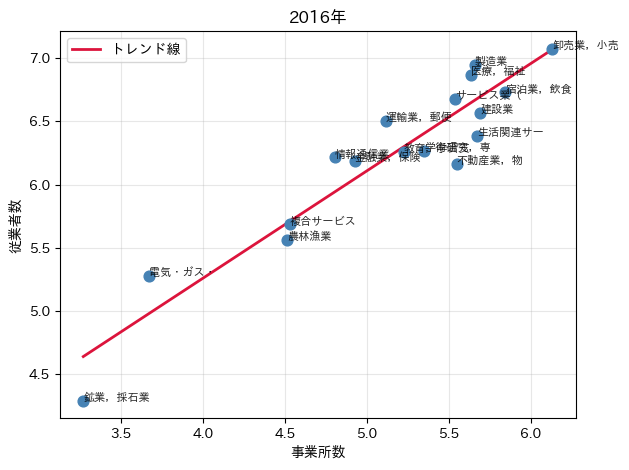

In [13]:
pyp.scatter_plot(x='e2016', y='w2016', data=df, xylog=True,
                 title='2016年', xlabel='事業所数', ylabel='従業者数',
                 text_col='産業'   # マーカー横に表示する名前が入っている列
)

横軸に2016年従業者数（常用対数）、縦軸に従業者数の変化率を使い、散布図を表示する。ただし、トレンド線は非表示とする。

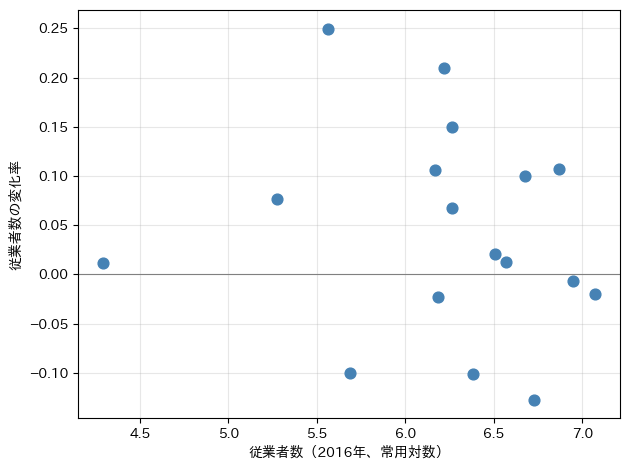

In [14]:
pyp.scatter_plot('w2016', 'w変化率', data=df,
                 xlabel='従業者数（2016年、常用対数）', ylabel='従業者数の変化率',
                 xlog=True,    # 横軸の変数を常用対数に変換
                 line=False,   # トレンド線を非表示
)

## 単回帰分析

In [15]:
help(pyp.regression)

Help on function regression in module py4project.core:

regression(x, y, data, robust=False, alpha=0.05, stars=True)
    最小二乗法（OLS）による回帰分析をおこなう。

    xを説明変数、yを被説明変数として回帰分析をおこない、
    結果を表にして返します。Colabのセルの最後に置くと表が表示されます。

    引数
    ----
    x : 文字列 または 文字列のリスト
        説明変数（yを説明するために使う変数）の列名。
        リストで複数指定すると重回帰分析になります。
        同じ列を重ねて指定したり、yと同じ列を指定したりはできません。
        例： x='特化係数'
        例： x=['特化係数', '事業所数']
    y : 文字列
        被説明変数（説明したい変数）の列名。
    data : DataFrame
        xとyの列を含むデータフレーム。
        xまたはyが欠けている行は、計算から自動的に除かれます。
    robust : True または False
        Falseなら通常の標準誤差（表には「非頑健」と表示）、
        Trueなら不均一分散に強い標準誤差（表には「不均一分散頑健(HC3)」と表示）
        を使います。
    alpha : 数値
        有意水準。信頼区間は (1 - alpha) × 100 ％ で計算されます。
        初期値0.05は95％信頼区間にあたります。
    stars : True または False
        Trueで「有意性」の列に星印を追加します。

    戻り値
    ------
    RegressionResult
        セルの最後に置くと結果表として表示されます。
        result.params のように statsmodels の属性も使えます。
        元のstatsmodelsのオブジェクトは result.result で取り出せます。

    表示される

次の推定式を使い回帰分析をおこなう。

$$
\text{従業者数}_i = b_0 + b_1 \times\text{事業所数}_i + u_i
$$

In [16]:
df['従業者数'] = df['w2016']
df['事業所数'] = df['e2016']
pyp.regression(x='事業所数', y='従業者数', data=df)

被説明変数：従業者数
サンプルの大きさ：17
決定係数：0.7398
自由度調整済み決定係数：0.7225
標準誤差の種類：非頑健
信頼区間の水準：95 ％

             推定値       p値       信頼区間下限       信頼区間上限  有意性
変数                                                      
定数項  693261.8110   0.2575 -562188.5921 1948712.2141     
事業所数      8.4421  <0.0001       5.6869      11.1973  ***

星印：*** p<0.01　** p<0.05　* p<0.1

### 結果を変数に入れる場合

`regression` は結果を返すため、変数に入れて後から使うことができる。

ただし変数に入れると、そのセルには**結果表が表示されない**。
表示したい場合は、次の行に変数名だけを書く。

In [17]:
res = pyp.regression(x='事業所数', y='従業者数', data=df)
res   # この行がないと結果表は表示されない

被説明変数：従業者数
サンプルの大きさ：17
決定係数：0.7398
自由度調整済み決定係数：0.7225
標準誤差の種類：非頑健
信頼区間の水準：95 ％

             推定値       p値       信頼区間下限       信頼区間上限  有意性
変数                                                      
定数項  693261.8110   0.2575 -562188.5921 1948712.2141     
事業所数      8.4421  <0.0001       5.6869      11.1973  ***

星印：*** p<0.01　** p<0.05　* p<0.1

結果からは、決定係数や係数などの個々の値を取り出すこともできる。

In [18]:
print('決定係数 :', res.rsquared)
print('係数     :')
print(res.params)

決定係数 : 0.7398238783742246
係数     :
const    693261.810971
事業所数          8.442091
dtype: float64


### 不均一分散に強い標準誤差

`robust=True` とすると、不均一分散に強い標準誤差（HC3）を使う。
係数の推定値は変わらないが、p値と信頼区間が変わる。

In [19]:
pyp.regression(x='事業所数', y='従業者数', data=df, robust=True)

被説明変数：従業者数
サンプルの大きさ：17
決定係数：0.7398
自由度調整済み決定係数：0.7225
標準誤差の種類：不均一分散頑健(HC3)
信頼区間の水準：95 ％

             推定値       p値    信頼区間下限       信頼区間上限  有意性
変数                                                   
定数項  693261.8110   0.0497 1034.3073 1385489.3146   **
事業所数      8.4421  <0.0001    6.9346       9.9496  ***

星印：*** p<0.01　** p<0.05　* p<0.1

### 信頼区間の水準を変える

`alpha` で有意水準を指定する。`alpha=0.01` は99％信頼区間にあたる。

In [20]:
pyp.regression(x='事業所数', y='従業者数', data=df, alpha=0.01)

被説明変数：従業者数
サンプルの大きさ：17
決定係数：0.7398
自由度調整済み決定係数：0.7225
標準誤差の種類：非頑健
信頼区間の水準：99 ％

             推定値       p値        信頼区間下限       信頼区間上限  有意性
変数                                                       
定数項  693261.8110   0.2575 -1042388.8804 2428912.5024     
事業所数      8.4421  <0.0001        4.6331      12.2511  ***

星印：*** p<0.01　** p<0.05　* p<0.1

## 重回帰分析

`x` にリストを渡すと、説明変数が複数の重回帰分析になる。

$$
\text{従業者数}_i = b_0 + b_1 \times\text{事業所数}_i + b_2 \times\text{事業所数の変化}_i + u_i
$$

In [21]:
df['事業所数の変化'] = df['e2021'] - df['e2016']
pyp.regression(x=['事業所数', '事業所数の変化'], y='従業者数', data=df)

被説明変数：従業者数
サンプルの大きさ：17
決定係数：0.7466
自由度調整済み決定係数：0.7104
標準誤差の種類：非頑健
信頼区間の水準：95 ％

                推定値      p値        信頼区間下限       信頼区間上限  有意性
変数                                                         
定数項     481886.5395  0.4984 -1005084.8347 1968857.9137     
事業所数         9.4725  0.0006        4.8908      14.0541  ***
事業所数の変化     10.3376  0.5493      -25.7978      46.4730     

星印：*** p<0.01　** p<0.05　* p<0.1

## 単回帰分析：散布図

In [22]:
help(pyp.regression_plot)

Help on function regression_plot in module py4project.core:

regression_plot(x=None, y=None, data=None, title=None, xlabel=None, ylabel=None, line=True, text_col=None, robust=False, *, ols_res=None)
    散布図に回帰直線を重ねて表示する。

    引数
    ----
    x : 文字列
        横軸にする変数（説明変数）の列名。
    y : 文字列
        縦軸にする変数（被説明変数）の列名。
    data : DataFrame
        xとyの列を含むデータフレーム。
        xまたはyが欠けている行は、作図と計算から自動的に除かれます。
    title : 文字列
        グラフの上に表示するタイトル。
        省略した場合、line=True なら推定式だけが、
        line=False ならタイトルなしになります。
    xlabel : 文字列
        横軸のラベル。省略するとxの列名がそのまま使われます。
    ylabel : 文字列
        縦軸のラベル。省略するとyの列名がそのまま使われます。
    line : True または False
        Trueで回帰直線を引き、推定式をタイトルに表示します。
    text_col : 文字列
        各点の横に表示する名前が入っている列名。
        省略すると名前は表示されません。
        例： text_col='産業'、text_col='都道府県'
        名前は先頭6文字までが表示されます。
    robust : True または False
        Falseなら通常の標準誤差、Trueなら不均一分散に強い標準誤差（HC3）
        を使います。回帰直線そのものはどちらでも変わりません。
    ols_res : regression の結果（キーワード指定のみ）
        regression で計算した結果を渡す

上の回帰分析の回帰直線とデータの散布図を表示する。

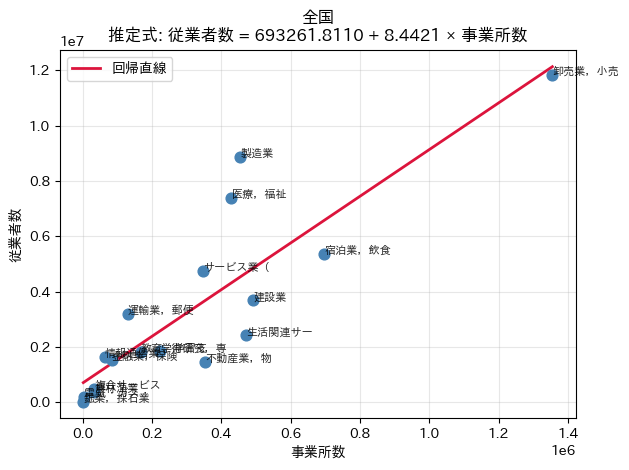

In [23]:
pyp.regression_plot(x='事業所数', y='従業者数', title='全国', data=df,
                    text_col='産業'    # マーカー横に表示する名前が入っている列
)

### 回帰分析の結果から図を描く

`regression` の結果を `ols_res` に渡すと、計算し直さずにその結果で図を描く。

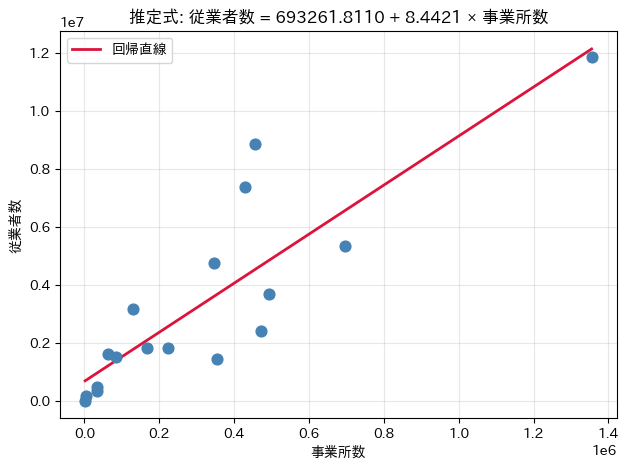

In [24]:
res = pyp.regression(x='事業所数', y='従業者数', data=df)
pyp.regression_plot(ols_res=res)